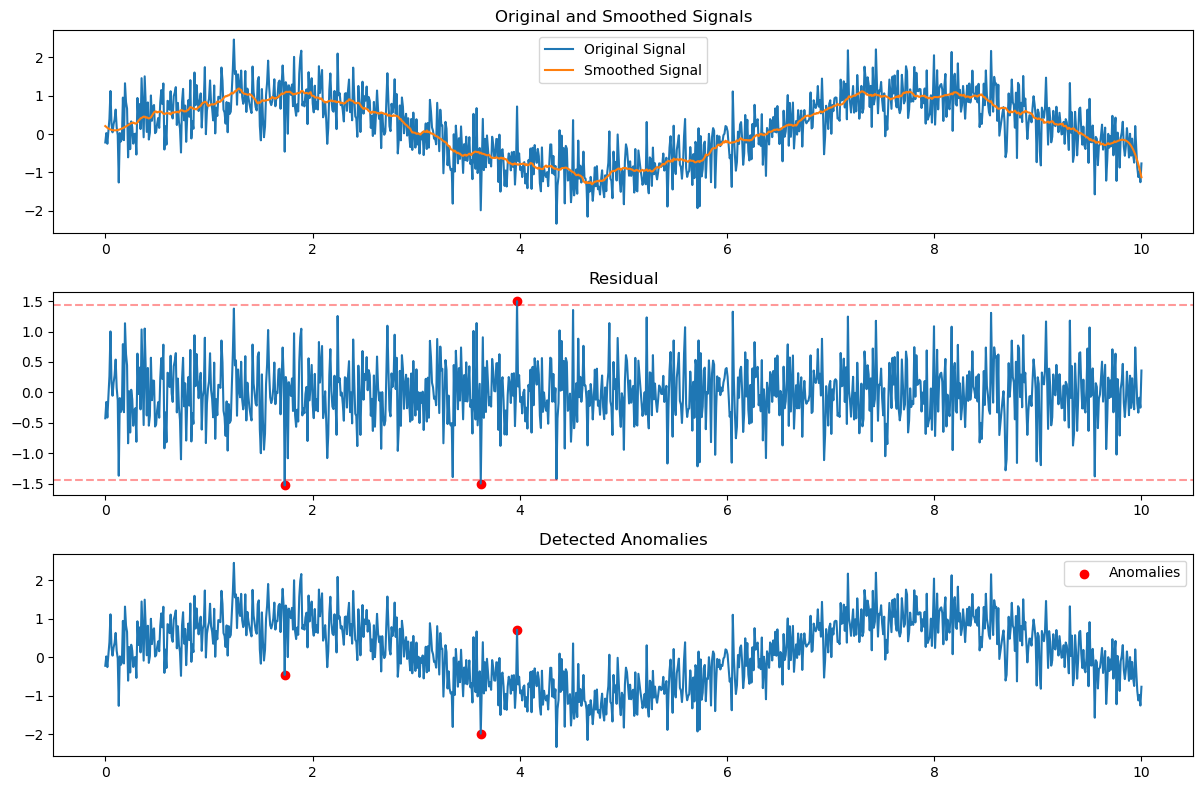

In [6]:
import numpy as np
from scipy.signal import savgol_filter
import matplotlib.pyplot as plt

# 예시 신호 생성
t = np.linspace(0, 10, 1000)
original_signal = np.sin(t) + 0.5 * np.random.randn(1000)

# SG 필터 적용
window_length = 51  # 윈도우 크기 (홀수여야 함)
polyorder = 3  # 다항식 차수
smoothed_signal = savgol_filter(original_signal, window_length, polyorder)

# Residual 계산
residual = original_signal - smoothed_signal

# Anomaly detection (간단한 임계값 기반)
threshold = 3 * np.std(residual)
anomalies = np.abs(residual) > threshold

# 결과 시각화
plt.figure(figsize=(12, 8))
plt.subplot(3, 1, 1)
plt.plot(t, original_signal, label='Original Signal')
plt.plot(t, smoothed_signal, label='Smoothed Signal')
plt.legend()
plt.title('Original and Smoothed Signals')

plt.subplot(3, 1, 2)
plt.plot(t, residual)
plt.axhline(threshold, color='red', linestyle='--', alpha=.4)
plt.axhline(-threshold, color='red', linestyle='--', alpha=.4)
plt.scatter(t[anomalies], residual[anomalies], color='red', label='Anomalies')
plt.title('Residual')

plt.subplot(3, 1, 3)
plt.plot(t, original_signal)
plt.scatter(t[anomalies], original_signal[anomalies], color='red', label='Anomalies')
plt.legend()
plt.title('Detected Anomalies')

plt.tight_layout()
plt.show()


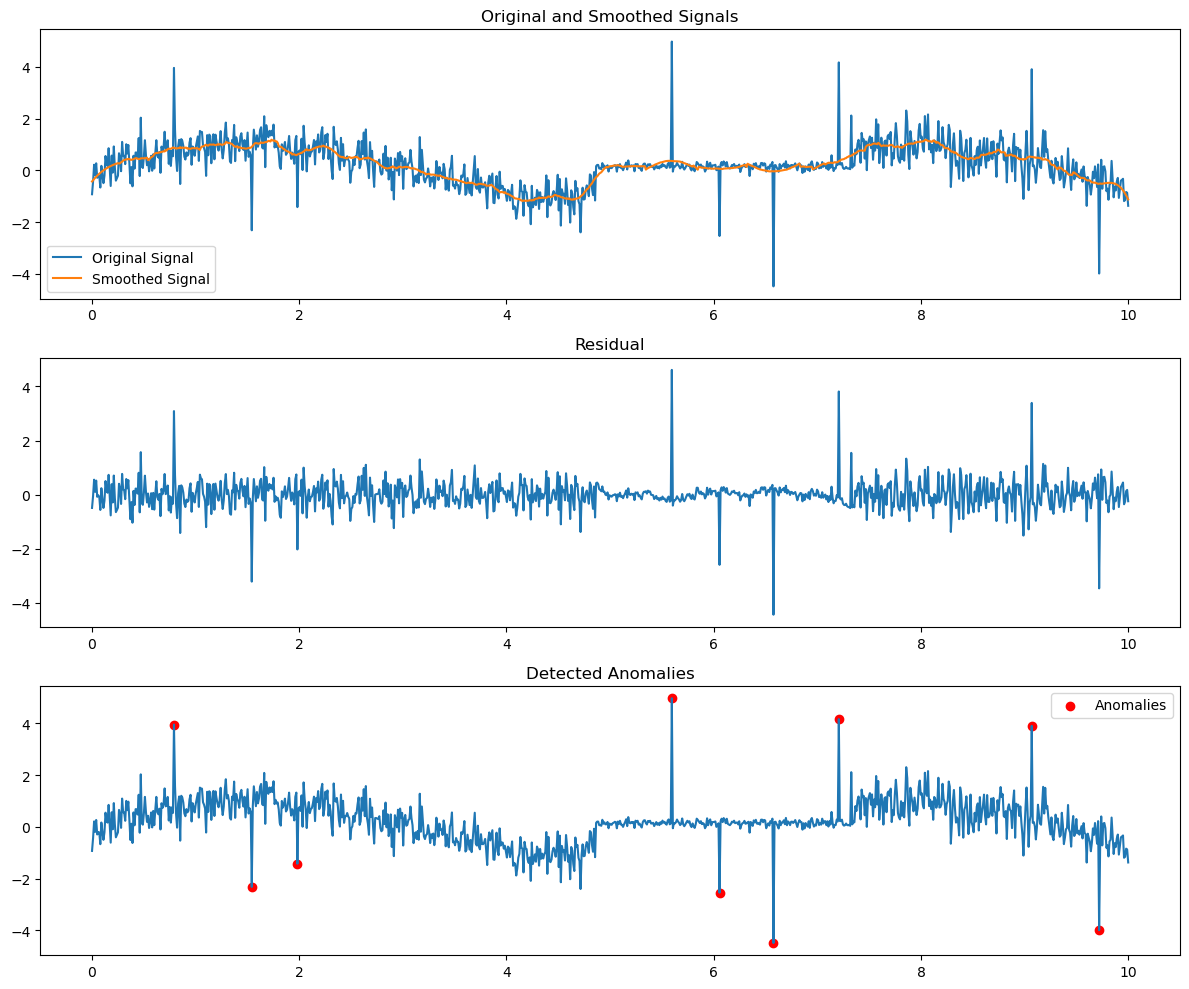

In [7]:
import numpy as np
from scipy.signal import savgol_filter
import matplotlib.pyplot as plt

# 예시 신호 생성
def generate_signal(n_samples, n_anomalies):
    t = np.linspace(0, 10, n_samples)
    signal = np.sin(t) + 0.5 * np.random.randn(n_samples)
    
    # 일정한 구간 추가
    constant_region = np.random.randint(n_samples // 4, n_samples // 2)
    signal[constant_region:constant_region + n_samples // 4] = np.mean(signal) + 0.1 * np.random.randn(n_samples // 4)
    
    # 이상치 추가
    anomaly_indices = np.random.choice(n_samples, n_anomalies, replace=False)
    signal[anomaly_indices] += np.random.choice([-1, 1], n_anomalies) * np.random.uniform(2, 5, n_anomalies)
    
    return t, signal

# 신호 생성
t, original_signal = generate_signal(1000, 10)

# SG 필터 적용
window_length = 51  # 윈도우 크기 (홀수여야 함)
polyorder = 3  # 다항식 차수
smoothed_signal = savgol_filter(original_signal, window_length, polyorder)

# Residual 계산
residual = original_signal - smoothed_signal

# Anomaly detection (Moving Average와 표준편차 기반)
def detect_anomalies(residual, window_size=50, threshold_factor=3):
    moving_mean = np.convolve(np.abs(residual), np.ones(window_size)/window_size, mode='same')
    moving_std = np.std(residual) * np.ones_like(residual)
    threshold = threshold_factor * moving_std
    return np.abs(residual) > threshold + moving_mean

anomalies = detect_anomalies(residual)

# 결과 시각화
plt.figure(figsize=(12, 10))
plt.subplot(3, 1, 1)
plt.plot(t, original_signal, label='Original Signal')
plt.plot(t, smoothed_signal, label='Smoothed Signal')
plt.legend()
plt.title('Original and Smoothed Signals')

plt.subplot(3, 1, 2)
plt.plot(t, residual)
plt.title('Residual')

plt.subplot(3, 1, 3)
plt.plot(t, original_signal)
plt.scatter(t[anomalies], original_signal[anomalies], color='red', label='Anomalies')
plt.legend()
plt.title('Detected Anomalies')

plt.tight_layout()
plt.show()

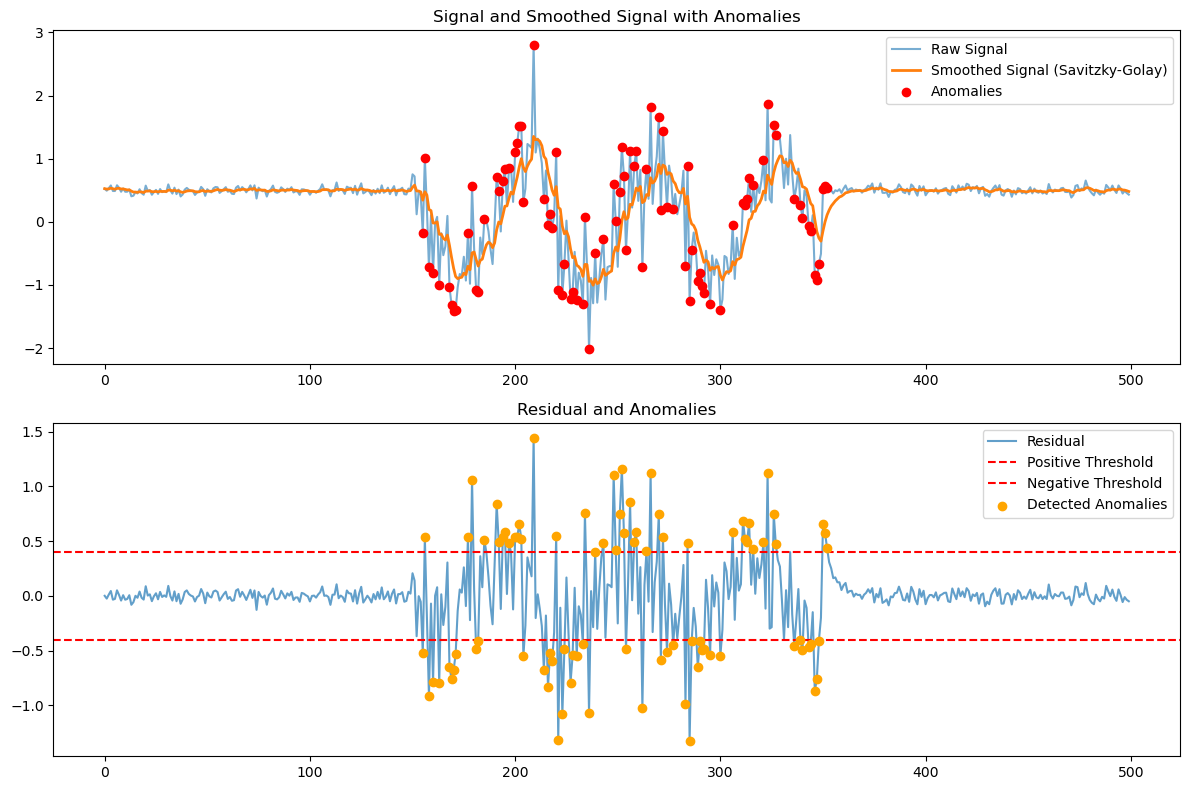

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter, medfilt

# 1. 데이터 생성
np.random.seed(42)
t = np.linspace(0, 10, 500)
constant_region = 0.5 + 0.05 * np.random.normal(size=150)  # Constant with noise
anomaly_region = np.sin(5 * t[150:350]) + 0.5 * np.random.normal(size=200)  # Peaks and large amplitude
constant_region_2 = 0.5 + 0.05 * np.random.normal(size=150)  # Constant with noise

raw_signal = np.concatenate([constant_region, anomaly_region, constant_region_2])

# 2. Savitzky-Golay 필터 스무딩
# smoothed_signal = savgol_filter(raw_signal, window_length=31, polyorder=3)

'''
median filter 기반 이상 감지
smoothed_signal = medfilt(raw_signal, kernel_size=31)
단기적으로 큰 peak를 잡아내는 데 탁월
'''

'''
wavelet denoising 기반 스무딩
import pywt
coeff = pywt.wavedec(raw_signal, 'db4', level=4)
threshold = 0.2 * np.std(coeff[-1])  # 노이즈 수준에 맞는 threshold
coeff[1:] = [pywt.threshold(c, threshold, mode='soft') for c in coeff[1:]]
smoothed_signal = pywt.waverec(coeff, 'db4')
'''

'''
alpha = 0.2  # Smoothing factor
smoothed_signal = [raw_signal[0]]  # 초기 값
for i in range(1, len(raw_signal)):
    smoothed_signal.append(alpha * raw_signal[i] + (1 - alpha) * smoothed_signal[-1])
smoothed_signal = np.array(smoothed_signal)
'''


# 3. Residual 계산
residual = raw_signal - smoothed_signal

# 4. 이상 감지 (Residual 기반)
threshold = 0.4  # Threshold for anomalies
anomalies = np.where(np.abs(residual) > threshold)[0]

# 5. 시각화
plt.figure(figsize=(12, 8))

# Raw Signal and Smoothed Signal
plt.subplot(2, 1, 1)
plt.plot(raw_signal, label="Raw Signal", alpha=0.6)
plt.plot(smoothed_signal, label="Smoothed Signal (Savitzky-Golay)", linewidth=2)
plt.scatter(anomalies, raw_signal[anomalies], color='red', label="Anomalies", zorder=5)
plt.legend()
plt.title("Signal and Smoothed Signal with Anomalies")

# Residual and Threshold
plt.subplot(2, 1, 2)
plt.plot(residual, label="Residual", alpha=0.7)
plt.axhline(threshold, color='red', linestyle='--', label="Positive Threshold")
plt.axhline(-threshold, color='red', linestyle='--', label="Negative Threshold")
plt.scatter(anomalies, residual[anomalies], color='orange', label="Detected Anomalies", zorder=5)
plt.legend()
plt.title("Residual and Anomalies")

plt.tight_layout()
plt.show()


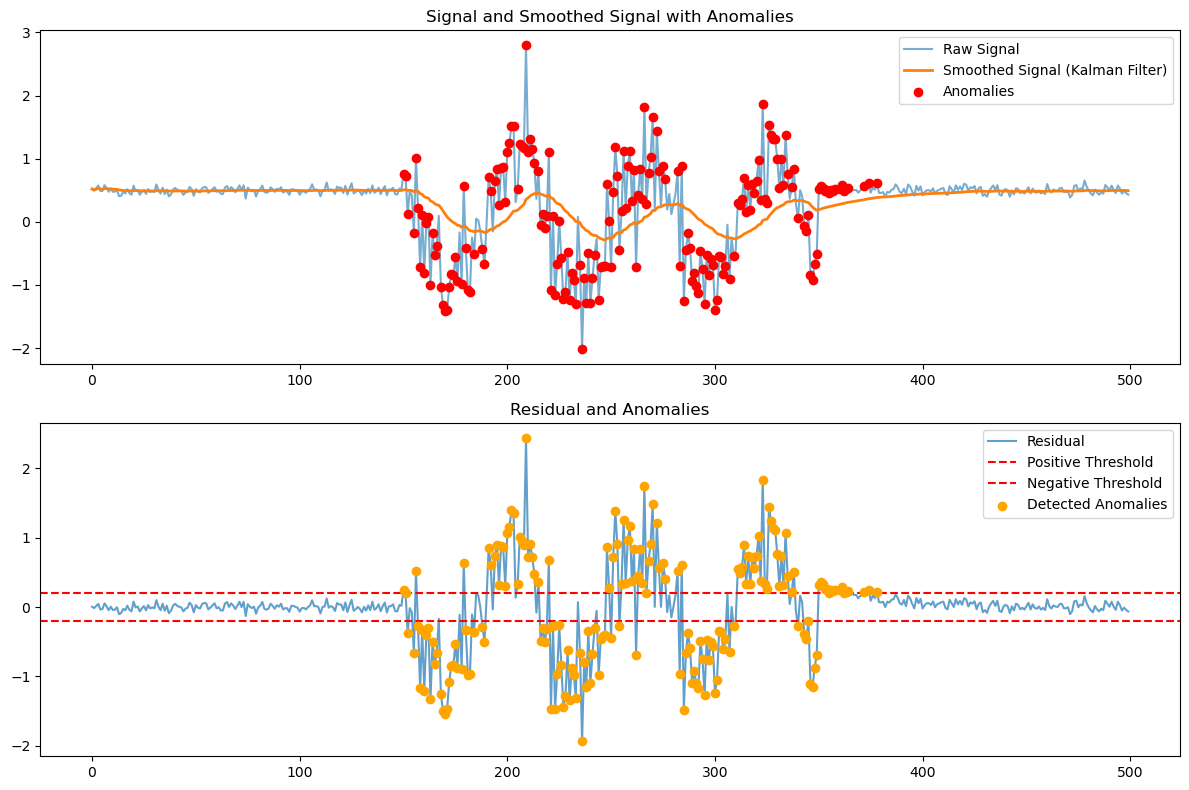

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 데이터 생성
np.random.seed(42)
t = np.linspace(0, 10, 500)
constant_region = 0.5 + 0.05 * np.random.normal(size=150)  # Constant with noise
anomaly_region = np.sin(5 * t[150:350]) + 0.5 * np.random.normal(size=200)  # Peaks and large amplitude
constant_region_2 = 0.5 + 0.05 * np.random.normal(size=150)  # Constant with noise

raw_signal = np.concatenate([constant_region, anomaly_region, constant_region_2])

# 2. 칼만 필터 구현
n = len(raw_signal)

# 칼만 필터 변수 초기화
x = 0.0  # 초기 상태 (예측값)
P = 1.0  # 초기 상태 추정의 불확실성 (공분산)
Q = 1e-5  # 프로세스 노이즈 공분산
R = 0.01  # 관측 노이즈 공분산
K = 0.0  # 칼만 이득

smoothed_signal = []

for z in raw_signal:
    # 2.1 Prediction 단계
    x_pred = x  # 상태 예측
    P_pred = P + Q  # 공분산 예측

    # 2.2 Update 단계
    K = P_pred / (P_pred + R)  # 칼만 이득 계산
    x = x_pred + K * (z - x_pred)  # 상태 갱신
    P = (1 - K) * P_pred  # 공분산 갱신

    # 결과 저장
    smoothed_signal.append(x)

# 3. Residual 계산
residual = raw_signal - np.array(smoothed_signal)

# 4. 이상 탐지 (Residual 기반)
threshold = 0.2  # 임계값 설정
anomalies = np.where(np.abs(residual) > threshold)[0]

# 5. 시각화
plt.figure(figsize=(12, 8))

# Raw Signal and Smoothed Signal
plt.subplot(2, 1, 1)
plt.plot(raw_signal, label="Raw Signal", alpha=0.6)
plt.plot(smoothed_signal, label="Smoothed Signal (Kalman Filter)", linewidth=2)
plt.scatter(anomalies, raw_signal[anomalies], color='red', label="Anomalies", zorder=5)
plt.legend()
plt.title("Signal and Smoothed Signal with Anomalies")

# Residual and Threshold
plt.subplot(2, 1, 2)
plt.plot(residual, label="Residual", alpha=0.7)
plt.axhline(threshold, color='red', linestyle='--', label="Positive Threshold")
plt.axhline(-threshold, color='red', linestyle='--', label="Negative Threshold")
plt.scatter(anomalies, residual[anomalies], color='orange', label="Detected Anomalies", zorder=5)
plt.legend()
plt.title("Residual and Anomalies")

plt.tight_layout()
plt.show()
